In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [57]:
df = pd.read_csv("../data/processed/df_final_eda.csv")

df.head()

,ID Estacion,Autoridad Ambiental,Estación,Latitud,Longitud,Variable,Unidades,Tiempo de exposición (horas),Año,Promedio,...,Mínimo,Fechas/horas del mínimo,Días de excedencias,Código del Departamento,Nombre del Departamento,Código del Municipio,Nombre del Municipio,Tipo de Estación,Ubicacion,tipo_outlier
0,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,DViento,deg,1,"2,011",256.8,...,1.3,29/11/2011 7:00,0,5,Antioquia,5308.0,Girardota,Fija,POINT (-75.443986 6.378517),Normal
1,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,DViento,deg,24,"2,011",257.4,...,99.7,8/11/2011 0:00,0,5,Antioquia,5308.0,Girardota,Fija,POINT (-75.443986 6.378517),Normal
2,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,PLiquida,mm,1,"2,011",4,...,1.5,07/11/2011 23:00:00 - 08/11/2011 05:00:00 - 13...,0,5,Antioquia,5308.0,Girardota,Fija,POINT (-75.443986 6.378517),Normal
3,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,P,mmHg,1,"2,011",645.9,...,641.6,27/10/2011 17:00,0,5,Antioquia,5308.0,Girardota,Fija,POINT (-75.443986 6.378517),Normal
4,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,P,mmHg,24,"2,011",645.9,...,644,27/10/2011 0:00,0,5,Antioquia,5308.0,Girardota,Fija,POINT (-75.443986 6.378517),Normal


In [58]:
df.columns

Index(['ID Estacion', 'Autoridad Ambiental', 'Estación', 'Latitud', 'Longitud',
       'Variable', 'Unidades', 'Tiempo de exposición (horas)', 'Año',
       'Promedio', 'Suma', 'No. de datos', 'Representatividad Temporal',
       'Excedencias limite actual', 'Porcentaje excedencias limite actual',
       'Mediana', 'Percentil 98', 'Máximo', 'Fechas/horas del máximo',
       'Mínimo', 'Fechas/horas del mínimo', 'Días de excedencias',
       'Código del Departamento', 'Nombre del Departamento',
       'Código del Municipio', 'Nombre del Municipio', 'Tipo de Estación',
       'Ubicacion', 'tipo_outlier'],
      dtype='object')

# APLICAMOS UN FORMATO A LA COLUMNA DEL DF DE FECHA/HORA DEL MINIMO DEBIDO A UN ERROR EN EL FORMATO ACTUAL

Se formatea la columna del df con la finalidad de contar con campos más legibles y limpios a la hora de hacer un procesamiento de los datos

In [59]:
df["Fechas/horas del mínimo"] = df["Fechas/horas del mínimo"].astype(str)

df["Fechas/horas del mínimo"] = df["Fechas/horas del mínimo"].str.split(" - ").str[0]

df["Fechas/horas del mínimo"] = df["Fechas/horas del mínimo"].str.replace(r"[^\d:/\s]", "", regex=True)

df["Fechas/horas del mínimo"] = df["Fechas/horas del mínimo"].str.strip()

df["Fechas/horas del mínimo"] = pd.to_datetime(
    df["Fechas/horas del mínimo"],
    errors="coerce",
    dayfirst=True
)

In [60]:
df["Fechas/horas del mínimo"] = pd.to_datetime(
    df["Fechas/horas del mínimo"],
    errors="coerce",
    dayfirst=True
)

In [61]:
df["Fechas/horas del mínimo"].head()
df["Fechas/horas del mínimo"].isnull().sum()

np.int64(16413)

In [62]:
df["min_mes"] = df["Fechas/horas del mínimo"].dt.month
df["min_año"] = df["Fechas/horas del mínimo"].dt.year

## PREPARACION DEL DATA SET (ELIMAR COLUMNAS POCO RELEVANTES)

Eliminamos las columnas que no aportan un valor significativo al analisis del proceso con el fin del  tener unos datos timpos y consistentes. 
- ID Estacion, Código del Departamento, Código del municipio: Estas variables no aportan información predictiva y solo nos permiten identificar registros. 
- Latitud, Longitud: Estas variables presentan baja correlación, se decide eliminar estas variables ya que no explican el fenomeno. 
- Suma, No. de datos, Mediana, Percentil 98: Estas variables son derivadas por lo que serian redundantes en nuestro dataset, al dejar estas variables nos generaria colinealidad. 


In [63]:
columnas_eliminar = [
    "Código del Departamento",
    "Código del Municipio",
    "Latitud",
    "Longitud",
    "ID Estacion",
    "Suma",
    "No. de datos",
    "Mediana",
    "Percentil 98"
]

df_modelo = df.drop(columns=columnas_eliminar, errors="ignore")

# CODIFICACIÓN DE VARIABLES CATEGORICAS

Se transforman las variables categóricas en variables numéricas mediante One-Hot Encoding.

Se aplicó la técnica de One-Hot Encoding para transformar las variables categóricas en variables numéricas binarias.

Se utilizó el parámetro `drop_first=True` para evitar multicolinealidad, eliminando una de las categorías y utilizando las restantes como referencia.

In [64]:
df_modelo = pd.get_dummies(df_modelo, drop_first=True)

# ESCALADO DE VARIABLES

Se aplica estandarización a las variables numéricas para garantizar que todas tengan la misma escala.

Se seleccionaron únicamente las variables numéricas del dataset para aplicar el proceso de estandarización.

Posteriormente, se utilizó el método StandardScaler para transformar las variables, garantizando que todas tengan media cero y desviación estándar uno.

Este proceso es fundamental para evitar que variables con diferentes escalas afecten el rendimiento de los modelos, especialmente en técnicas como PCA.

In [65]:

df_numerico = df_modelo.select_dtypes(include=[np.number])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numerico)

df_scaled = pd.DataFrame(df_scaled, columns=df_numerico.columns)

#  APLICAMOS PCA PARA REDUCCIÓN DE DIMENSIONALIDAD 

Se aplica Análisis de Componentes Principales (PCA) para reducir la dimensionalidad del dataset y facilitar la visualización de patrones.

In [66]:
df_numerico = df_modelo.select_dtypes(include=[np.number])

df_numerico = df_numerico.dropna()

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numerico)

df_scaled = pd.DataFrame(df_scaled, columns=df_numerico.columns)

# CONCLUSIONES DE LA VISUALIZACIÓN 

Al evidenciar una concentración amplia cerca del centro nos indica que el dataset maneja una buena homogeneidad en la mayoria de sus datos. Aunque contamos con presencias de algunos puntos alejados a la izquierda (PC1 y a la derecha PC2) los cuales podremos catalogar como los puntos extremos de contaminacion siendo estos puntos claves del analisis actual y que no podremos retirar debido a la completitu del dataset. 
A pesar de contar con alguna disperción de los datos vemos que la nube de disperción es algo moderada lo que indica que tenemos variabilidad en los datos. 
Al evidenciar la nube ligeramente inclinada podemos concluir que tenemos relación evidente entre variables  y nuestro PCA está capturando la estructura real del dataset.

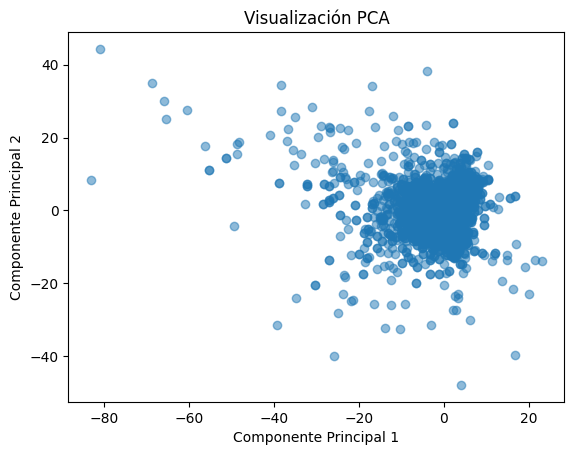

In [67]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.5)
plt.title("Visualización PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

In [ ]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(df_scaled)

print("Varianza explicada por cada componente")
print(pca.explained_variance_ratio_)


Varianza explicada por cada componente:
[0.34878595 0.16817653]


/Users/paraveraz/Documents/Analisis de datos/Examen Datos 2/Data-Analysis-2/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/paraveraz/Documents/Analisis de datos/Examen Datos 2/Data-Analysis-2/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/paraveraz/Documents/Analisis de datos/Examen Datos 2/Data-Analysis-2/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


# ANALISIS DE INSIGHTS PRINCIPALES 

A partir del analisis exploratorio realizado e implementando PCA, identificamos algunos casos puntuales y especificos tales como: 

- Valores extremos relevantes, que estos fueron considerados outliers pero debido a la naturalidad del dataset no son cobsideraos errores, sino datos que representan eventos "criticos de contaminación, por lo que no se eliminaron, se graficaron y analizaron para comprender su comprtamiento. 
- Estructura homogenea de los datos: En nuestro PCA  evidenciamos un alta concentración de datos en la región cenral de la grafica, esto nos ayudo a identificar que nuestro dataset presenta una buena homogeneidad y validez en los datos. 
- Dispersión de datos poco relevante: Aunque evidenciamos una breve dispersión de datos a la derecha esta no suele ser critico. 
- Nustro PCA logró explicar aproximadamete ub 51% del dataset , lo que puede concluirse que nuestro dataset suele ser un poco complejo y no pudo ser reducido completamente a pocas dimensiones sin perder información valiosa. 
- Relación fuerte entre variables de contaminación. Se encontró una alta correlación entre:
     * Excedencias límite actual
     * Porcentaje de excedencias
     * Días de excedencias

## PROBELAS DETECTADOS 
- Presencia de valores faltantes en variables temporales debido a formatos inconsistentes
- Registros con formatos incorrectos en fechas (rangos, caracteres inválidos)
- Variables categóricas con inconsistencias en nombres (ej: duplicados como "Bogotá" y "Bogotá, D.C.")
- Presencia de outliers extremos en variables clave

